<a href="{{ colab_base_laboratorios }}/Laboratorio_08_clasificacionLogistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Lab 8: Clasificacion Logística

Si deseamos clasificar algún tipo de imagen, resultado en campos medicos, astrofisicos se pueden aplicar algoritmos de clasificación. En particular en esta sesión se estudia los principios basicos de  regresión logística para aplicarla a los  modelos de clasificación.

Supongamos que queremos clasificar un sistema que tiene dos tipos posibles (los llamaremos los tipos 0 y 1) basado en dos características (correspondiente a dos variables X1 y X2) :



In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification,make_circles
import numpy as np

Text(0, 0.5, 'X_2')

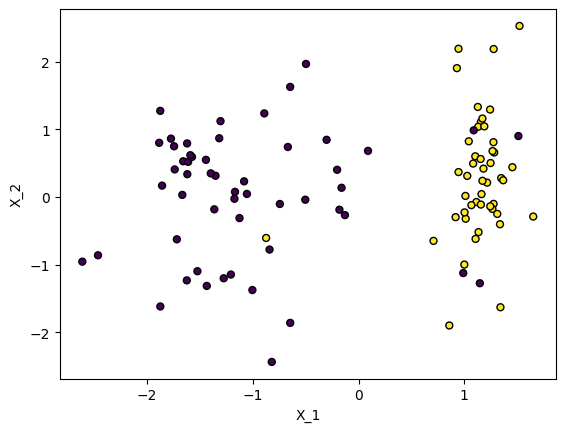

In [4]:
#Vamos a crear los datos de dos tipos introduciendo un porcentaje de
#valores con "ruido" (flip_y). Pruebe a cambiar el valor
X1, Y1 = make_classification(
    n_features = 2, n_redundant = 0, n_informative=1, n_clusters_per_class=1,
    random_state = 1, class_sep=1.2, flip_y = 0.15)
plt.figure()
plt.scatter(X1[:, 0], X1[:, 1], marker="o", c=Y1, s=25, edgecolor="k")
plt.xlabel("X_1")
plt.ylabel("X_2")

En este caso cada color representa los objetos tipos 0 y tipo 1. Para aplicar un algoritmo de clasificación relacionaremos el valor $h_{\theta}(X^{i}=x)$ con la probabilidad de obtener un valor de y dado un x parametrizado por $\theta$, $P(y=1|X=x;\theta)$, asi :

 $h_{\theta}(X^{i}=x) = P(y=1|X^{i};\theta) $

 Tenemos que:  $P(y=1|x;\theta)+P(y=0|x;\theta) = 1$

Si tenemos muestra equiprobables, podemos definir lo siguiente  para P :

- $P<0.5$ se obtienen los objetos tipo 0
- $P \geq 0.5$ se obtienen los objetos tipo 1

Podemos establecer un clasificador de los  sistemas basado en las probabilidades a partir de un clasificador logístico:


\begin{equation}
f(z)=\frac{1}{(1+e^{-z})}
\end{equation}
Cuya derivada es :

\begin{equation}
f'(z)=f(z)(1-f(z))
\end{equation}



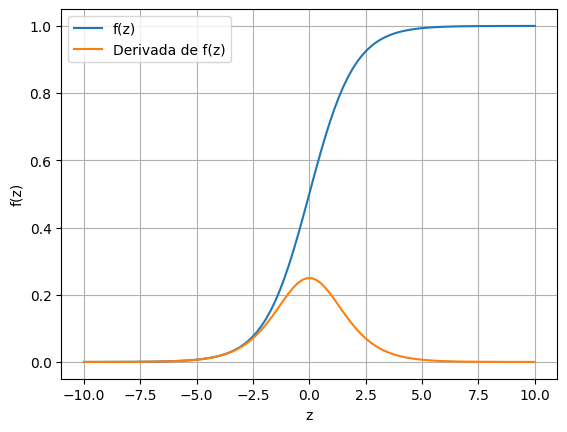

In [5]:
f = lambda x: 1/(1+np.exp(-x))
fp = lambda x: f(x)*(1-f(x))
z=np.linspace(-10, 10, 100)

plt.figure()
plt.plot(z,f(z), label="f(z)")
plt.plot(z,fp(z), label="Derivada de f(z)")
plt.ylabel("f(z)")
plt.xlabel("z")
plt.grid()
plt.legend()

- Para valores de $z< 0.0$ la regresión logistica clasica objetos tipo 0, siendo $f(z)<0.5$
- Para valores de $z\geq 0.0$ la regresión logística clasica objetos tipo 1 siendo $f(z) \geq  0.5$

¿Cual es la probabilidad de que dado un hyperplano, los valores de un hyperlado sean objetos tipo 0 o tipo 1?

Aplicando la regresión logistica, a las regresiones multivariadas estudiadas en la sesiones anteriores, tenemos que el argumento $z=\Theta^{T} X$, así:


\begin{equation}
h_{\theta}(X)=\frac{1}{(1+e^{-\Theta^T X})}
\end{equation}


- Se cumple que para los valores del hyperplano  $\Theta^T X\geq 0.0$, $y = 1$
- Se cumple que para  $\Theta^T X < 0.0$ , $y = 0$


Las condiciones anteriores permiten definir fronteras de desicion entre los datos a clasificar. Para los datos dados arriba, se puede establecer el siguiente clasificador.


$h_\theta(x) = g(\theta_0+\theta_1 x_1+\theta_2 x_2 ) $.

Una clasificación del dataset nos sugiere que la frontera para este dataset es:

$\theta_0+\theta_1 x_1+\theta_2 x_2 \geq 0.0$

Si por algun metodo encontramos que los parametros $\Theta$ entonces podemos definir la frontera de clasifiación. Como ejemplo supongamos que encontramos los siguientes parametros $\Theta=[3.0, -20, 1.0]$

Ecnontrar la ecuacion de la recta y mejorar la parametrizacion

$3-20x1+x2=0$

$x_2= 20 x_1 - 3$

In [6]:
x1 = np.linspace(0, 0.29, 100)
x2 = 20*x1-3

Text(0, 0.5, 'X_2')

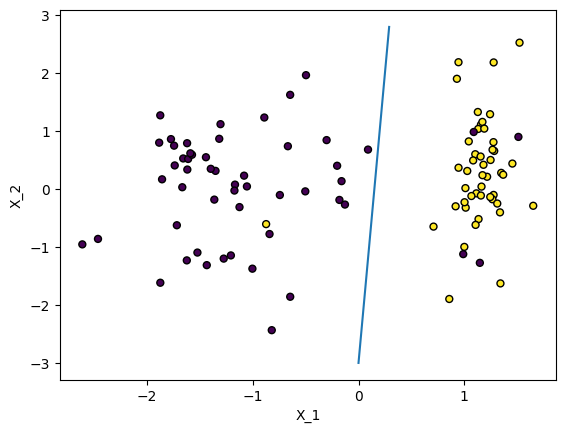

In [7]:
X1, Y1 = make_classification(
    n_features = 2, n_redundant = 0, n_informative=1, n_clusters_per_class=1,
    random_state = 1, class_sep=1.2, flip_y = 0.15)
plt.figure()
plt.scatter(X1[:, 0], X1[:, 1], marker="o", c=Y1, s=25, edgecolor="k")
plt.plot(x1, x2)
plt.xlabel("X_1")
plt.ylabel("X_2")

Se revisa el signo de $\Theta^T X$ en la exponencial para mantener la forma estándar de la sigmoide.

Fronteras no lineal también puede ser consideradas, para ello se puede definir  $\Theta^T X$ como funcion de un polinomio, por ejemplo

$\Theta^T X =  \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \theta_3 x_1^2 +\theta_4 x_2^2$

\begin{equation}
h_\theta(X) =  \frac{1}{1+e^{-(\theta_0 + \theta_1 x_1 + \theta_2 x_2 + \theta_3 x_1^2 +\theta_4 x_2^2)}}
\end{equation}

La frontera de desición en este caso esta determinada por:

$\theta_0 + \theta_1 x_1 + \theta_2 x_2 + \theta_3 x_1^2 +\theta_4 x_2^2 \geq 0$
para obtener un clasificador con valores de y = 1.

Para este mismo caso, supongamos que tenmos la siguiente distribución de datos, ¿Cuál es el mejor elección de parámetros $\Theta$ que permite clasificar los datos siguientes:







(np.float64(-1.12244940477901),
 np.float64(1.1839643638442499),
 np.float64(-1.2696420440360447),
 np.float64(1.185918477713659))

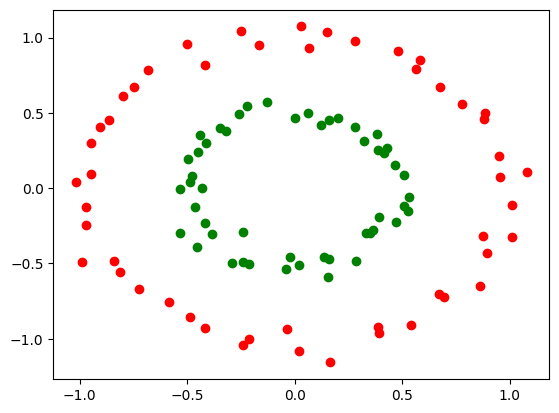

In [8]:
X, y = make_circles(
    n_samples=100, factor=0.5, noise=0.05, random_state=0)
red = y == 0
green = y == 1
f, ax = plt.subplots()
ax.scatter(X[red, 0], X[red, 1], c="r")
ax.scatter(X[green, 0], X[green, 1], c="g")
plt.axis("tight")

Analizando el conjunto de datos, se puede observar que la frontera es la de una circunferencia con centro en (0, 0) y radio de 0.7 aproxidamente,  asi nuestra elección de parámetros para el polinomio ejemplicado en la celda anterior ($\theta_0 + \theta_1 x_1 + \theta_2 x_2 + \theta_3 x_1^2 +\theta_4 x_1^4 \geq 0$ ) es:


$\Theta^T = [-0.7,0, 0, 1,1 ] $

Reemplando tenemos que:

$-0.7+x_1^2+x_2^2 \geq 0$

$x_1^2+x_2^2 \geq 0.7$

Text(0, 0.5, 'X_2')

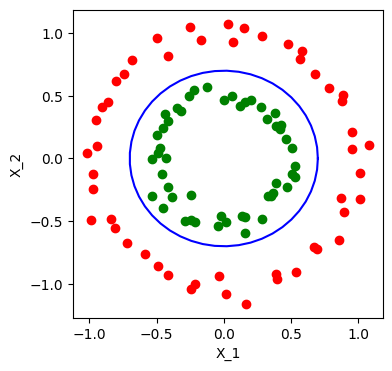

In [9]:
#Por motivos graficos transformemos la ecuación anterior parametrizada
#por theta

alpha = np.linspace(0, 2*np.pi)
x1=0.7*np.cos(alpha)
x2=0.7*np.sin(alpha)

X, y = make_circles(
    n_samples=100, factor=0.5, noise=0.05, random_state=0)
red = y == 0
green = y == 1

f, ax = plt.subplots(figsize=(4,4))
ax.scatter(X[red, 0], X[red, 1], c="r")
ax.scatter(X[green, 0], X[green, 1], c="g")

plt.plot(x1, x2,"b-")
plt.axis("tight")
plt.xlabel("X_1")
plt.ylabel("X_2")

De forma general, ¿Cómo pueden ser elegidos los valores de $\Theta$?.



Para todo el conjunto de datos, tenemos que:

Sea $\Theta^T = [\theta_0,\theta_1,\theta_2,...,\theta_n]$ una matrix $1 \times (n+1)$ y  


\begin{equation}
X =
\begin{bmatrix}
1& 1 & 1 & .&.&.&1\\
x_1^{(1)}&x_1^{(2)} & x_1^{(3)} & .&.&.&x_1^{(m)}\\
.&. & . &.&.&.& .\\
.&. & . & .&.&.&.\\
.&. & . & .&.&.&.\\
x_n^{(1)}&x_n^{(2)} & x_n^{(3)} & .&.&.&x_n^{(m)}\\
\end{bmatrix}_{(n+1) \times m}
\end{equation}


\begin{equation}
h_\theta (x)= \frac{1}{1+e^{-\Theta ^T (X)}}
\end{equation}



Para ello, podemos definir la función de coste como :


\begin{equation}
J = \left \{
  \begin{array}{ c l }
    -\log h(x) & \quad \textrm{if } y = 1 \\
    -\log (1-h(x))  & \quad \textrm{if } y = 0 \\
  \end{array}
\right.
\end{equation}



Resumida en la siguiente expresión:


$ J (\Theta) =\frac{1}{m} \sum_{i=1}^{m} \left[-y\log (h_{\theta}(X ^ {i})) - (1-y)\log (1-h_{\theta}(X^{i})) \right]$

Esta función de coste permite establecer el mejor clasificadose para la regresión logistica de acuerdo a la teoría de probabilidad. Se garantiza que cuando $P(y=1|x,\theta)$ se cumple la función de coste se minimiza, penalizando los valores que sean iguales a $P(y=0|x,\theta)$, analogamente, se cumple que cuando $P(y=0|x,\theta)$ se cumple la función de coste se minimiza, penalizando los valores que sean iguales a $P(y=1|x,\theta)$.
La metrica empleada para la regresión lineal no es recomedada en este caso, dado que la funcion de coste puede presentar múltiples minimos que dificultan la minimizacion  a través de algunas de las técnicas empleadas. Una justificación adicional para la métrica  es dada mas adelante segun la teoria de la probabilidad.

Se deja como tarea motrar que:

\begin{equation}
\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m}\sum_{i=1}^{m}[-y^{(i)}+h_\theta X^{(i)}] X_j^{(i)}
\end{equation}

Para la demostración, muestre que:
- $f'(z)= f(z)(1-f(z))$ usando que $f(z)=\frac{1}{1+e^{-z}} $
- $\frac{\partial h_{\theta}}{\partial \theta_j } = h_{\theta}(X^{(i)})(1-h_{\theta}(X^{(i)}))X_j^{(i)}$


La derivada permite aplicar el gradiente descendente para minimizar nuestra función de coste asi,  nuestro algoritmo de minimizacion permite encontrar los valores de $\theta$ despues de un conjunto determinado de itereaciones.

$\theta_j: \theta_j - \alpha \frac{\partial J}{\partial \theta_j}$


Otros metodos de minizacion podrian ser aplicados, tales como:


[Gradiente conjugado ](https://es.wikipedia.org/wiki/M%C3%A9todo_del_gradiente_conjugado#:~:text=En%20matem%C3%A1tica%2C%20el%20m%C3%A9todo%20del,son%20sim%C3%A9tricas%20y%20definidas%20positivas.&text=Varios%20m%C3%A9todos%20del%20gradiente%20conjugado,de%20las%20ecuaciones%20no%20lineales)

[BFGS](https://en.wikipedia.org/wiki/Broyden%E2%80%93Fletcher%E2%80%93Goldfarb%E2%80%93Shanno_algorithm)


[L-BGFS](https://en.wikipedia.org/wiki/Limited-memory_BFGS)

[Newton-Rhapson](https://en.wikipedia.org/wiki/Newton%27s_method)


# Interpretación probabilística


¿Qué tan adeacuado es la elección de $J(\theta)$  para el modelo de regresion logistica?



\begin{equation}
P(y=1|x;\theta)= h_{\theta}(X^{(i)})
\end{equation}

\begin{equation}
P(y=0|x;\theta)= 1-h_{\theta}(X^{(i)})
\end{equation}



\begin{equation}
P(y|x;\theta)=[h_{\theta}(X^{(i)})]^{y}[1-h_{\theta}(X^{(i)})]^{1-y}
\end{equation}

Asumiendo que los datos de entrenamiento son independientes:

$\cal{L}(\theta)=p(\vec{y}|x, \theta)$

\begin{equation}
\cal{L}(\theta)=\prod_{i=1}^{m} [h_{\theta}(X^{(i)})]^{y}[1-h_{\theta}(X^{(i)})]^{1-y}
\end{equation}

tomando el logaritmo:


\begin{equation}
\log \cal{L}(\theta)= \sum_{i=1}^{m} y \log h_{\theta}(X^{(i)}) + (1-y)\log (1-h_{\theta}(X^{(i)}))
\end{equation}

Los datos a considerar son los mas probables es decir que para encontrar los valores de $\theta$ que nos garantizan la maxima probabilidad es necesario maximar la función anterior. Despues de realizar los calculos se puede mostrar la ecuación dada para el gradiente de la función de coste.



En conclusión se cumple que:

Para todo el conjunto de datos, tenemos que:

Sea $\Theta^T = [\theta_0,\theta_1,\theta_2,...,\theta_n]$ una matrix $1 \times (n+1)$ y  


\begin{equation}
X =
\begin{bmatrix}
1& 1 & 1 & .&.&.&1\\
x_1^{(1)}&x_1^{(2)} & x_1^{(3)} & .&.&.&x_1^{(m)}\\
.&. & . &.&.&.& .\\
.&. & . & .&.&.&.\\
.&. & . & .&.&.&.\\
x_n^{(1)}&x_n^{(2)} & x_n^{(3)} & .&.&.&x_n^{(m)}\\
\end{bmatrix}_{(n+1) \times m}
\end{equation}


\begin{equation}
h_\theta (x)= \frac{1}{1+e^{\Theta ^T X}}
\end{equation}



- Función de coste
$ J (\Theta) =\frac{1}{m} \sum_{i=1}^{m} \left[-y\log (h_{\theta}(X ^ {i})) - (1-y)\log (1-h_{\theta}(X^{i})) \right]$

- Derivada de la funcion de coste
\begin{equation}
\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m}\sum_{i=1}^{m}[-y^{(i)}+h_\theta X^{(i)}] X_j^{(i)}
\end{equation}





# Regularización


## Regresion Logistica
Disminuir la complejidad del algoritmo




- Función de coste
\begin{equation}
J (\Theta) =\frac{1}{m} \sum_{i=1}^{m} \left[-y\log (h_{\theta}(X ^ {i})) - (1-y)\log (1-h_{\theta}(X^{i})) \right] + \frac{\lambda}{2m}\sum_{i=1}^{n} \theta_i^2
\end{equation}



- Derivada de la funcion de coste
\begin{equation}
\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m}\sum_{i=1}^{m}[-y^{(i)}+h_\theta X^{(i)}] X_j^{(i)} + \frac{\lambda}{m} \theta_j
\end{equation}


El gradiente descendente puede ser escrito como:


\begin{equation}
\theta_j := \theta_j\left(1-\alpha \frac{\lambda}{m} \right) - \frac{\alpha}{m}\sum_{i=1}^{m}[h_\theta X^{(i)}- y^{(i)}] X_j^{(i)}
\end{equation}



### Normal equation
\begin{equation}
\theta=(X^TX\lambda L)^{-1} X^T y
\end{equation}

\begin{equation}
\lambda=\begin{bmatrix}
0 & 0 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 1 \\
\end{bmatrix}
\end{equation}

Las dimensiones de $[\lambda]=(\mathrm{n+1}) \times (\mathrm{n+1})$



## Regresion Logistica
Disminuir la complejidad del algoritmo




- Función de coste
\begin{equation}
J (\Theta) =\frac{1}{m} \sum_{i=1}^{m} \left[-y\log (h_{\theta}(X ^ {i})) - (1-y)\log (1-h_{\theta}(X^{i})) \right] + \frac{\lambda}{2m}\sum_{j=1}^{n} \theta_j^2
\end{equation}



- Derivada de la funcion de coste
\begin{equation}
\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m}\sum_{i=1}^{m}[y^{(i)}-h_\theta X^{(i)}] X_j^{(i)} + \frac{\lambda}{m} \theta_j
\end{equation}


El gradiente descendente puede ser escrito como:


\begin{equation}
\theta_j := \theta_j\left(1-\alpha \frac{\lambda}{m} \right) - \frac{\alpha}{m}\sum_{i=1}^{m}[h_\theta X^{(i)}- y^{(i)}] X_j^{(i)}
\end{equation}



# Tomar el [iris dataset](https://en.wikipedia.org/wiki/Iris_flower_data_set) desde sklearn:

```
from sklearn import datasets

iris = datasets.load_iris()
```
- Realizar la clasifición de las tres clases  a traves de una regresión logística  y realizar multiclasicación, para ello considere lo siguiente:

Si en un dataset existen más de 2 clases, $y={0, 1, 2, 3, ...}$ se debe construir una multiclasificación, una contra todos, la estrategia sugerida es la siguiente.

Sea A, B, C las tres clases. Para estos valores definir:

1. Definir la clase A como la clase 0 y todas las otras B, C como la clase 1
2. Encontrar el valor $h_\theta(X) = P(y=A|x;\theta)$
3. Definir la clase B como la clase 0 y todas las otras A, C como la clase 1
4. Encontrar el valor $h_\theta(X) = P(y=B|x;\theta)$
5. Definir la clase C como la clase 0 y todas las otras A, B como la clase 1
6. Encontrar el valor $h_\theta(X) = P(y=C|x;\theta)$


Estrategia de solución.

1. Para tener una vision general de los datos analiza lo que contiene la clave DESCR del dataset
```
print(iris.DESCR)
```
2. Construye un dataframe:
- los datos se pueden encontrar con la clave "data".
- los nombres de las caracteristicas con la clave: "names_features"
- La clave target nos permite indentificar el tipo de datos.


3. Cambia el nombre de las columnas del dataframe, empleando intrucción como:
```
columns_name =[ "".join([c.capitalize() for c in cols.split()])  for cols in df.columns ]
columns_name =[col.replace("(" ,"_") for col in columns_name ]
cols = [col.replace(")" ,"") for col in columns_name ]
```


4. Analizar el dataframe, numeros de datos, cantidad de null, descripción del dataframe.

5. Aplica estadística básica y construye graficas para entender el dataset. Encuentra la matriz de correlacion


6. Encontrar la matrix de correlacion, emplear el metodo corr(), dentro de seaborn buscar el metodo heatmap() para realizar un grafico de la matrix de correlación.


7. Separar los datos en datos de entramiento y test, prueba la siguiente instruccion:
```
split = StratifiedShuffleSplit(n_splits = 1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(df, df["Target"]):
  strat_train_set = df.loc[train_index]
  strat_test_set = df.loc[test_index]
```
¿Cómo se estan seprando los datos?


8. Construye un modelo empleando una regresión logística, para clasificar la clase setosa y no setosa, emplea la libreria sklearn.


9. Determine  la frontera de clasificación:
```
X_new = np.linspace(-10, 10, 1000).reshape(-1, 1)#Generamos los valores de X_new
prob = log_reg.predict_proba(X_new)

decision_boundary = X_new[prob[:, 0] >= 0.5][0]
decision_boundary
```


10. Encontrar una gráfica de la regresión logística  con los valores de probabilidad


11. Construye el multiclasificador. Puede emplear los metodos dentro de logistic regresión.


12. Dado X = [4.9,5.0, 1.8, 0.3] asociados a todas las caracteristicas, ¿cuál es la probabilidad de que la flor sea setosa, versicolor o virginica?




Ayudas para mejorar las metricas:


- Normalizar cada columna respecto a su media y desviacion estandar

```
(x-mean(x))/std(x)
```

- Determinar los datos outlier

- Construir curvas de aprendizaje

# [SOFTMAX REGRESION](https://es.wikipedia.org/wiki/Funci%C3%B3n_SoftMax)


La elección anterior es conocida com softmax regresión, que permite definir un conjunto de probabilidades asociadas a un conjunto de clases. Al definir el maximo valor de la probabilidad dado un conjunto de inputs se tiene el objeto que predice el modelo, una forma de hacer una implementación rapida es mostrada a continuación.

[Referencias]  [Hand on Machine learning](https://github.com/ageron/handson-ml/blob/master/04_training_linear_models.ipynb)


# Reto, no es obligatorio.

### Clasificación de pulsar.

Para el siguiente  dataset descrito en el este enlace [pulsar](https://archive.ics.uci.edu/ml/datasets/HTRU2)  , construir un clasificador logístico, para ello, deberá primera entender las caracteristicas del problema y seguidamente estudiar el comportamiento de la clasificacion realizada.


1. Dividir los datos en train and test
2. Entrenar el algoritmo.
3. Analizar las curvas de aprendizaje.
4. Realizar Predicciones
5. Aplicar regularización.

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  Target TargetName
0            5.1           3.5            1.4           0.2       0     setosa
1            4.9           3.0            1.4           0.2       0     setosa
2            4.7           3.2            1.3           0.2       0     setosa
3            4.6           3.1            1.5           0.2       0     setosa
4            5.0           3.6            1.4           0.2       0     setosa
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Target         150 non-null    int64  
 5   TargetName     150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
       S

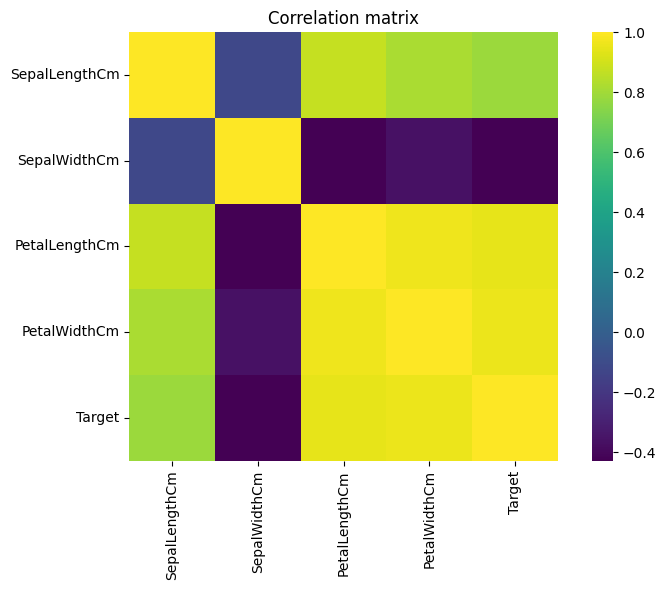

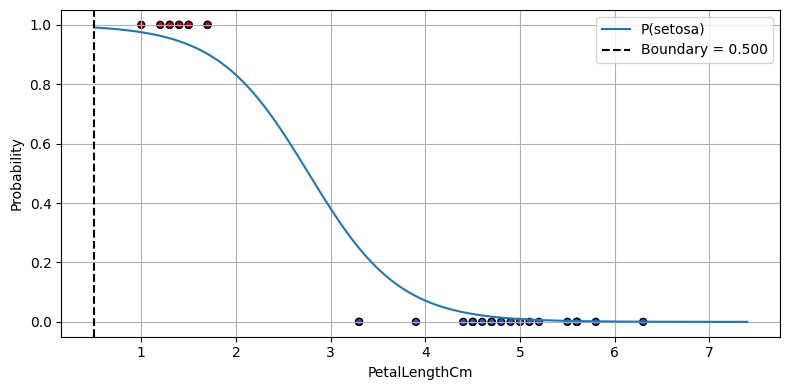

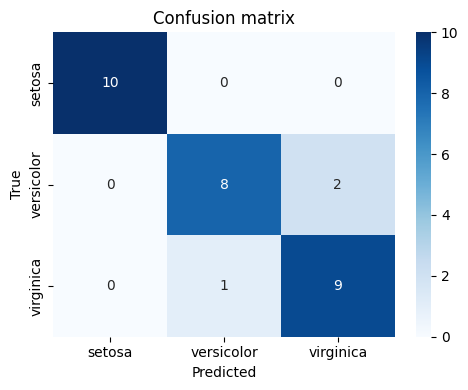

In [2]:
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

iris = load_iris()
feature_names = [
    'SepalLengthCm',
    'SepalWidthCm',
    'PetalLengthCm',
    'PetalWidthCm',
]

df = pd.DataFrame(iris.data, columns=feature_names)
df['Target'] = iris.target
df['TargetName'] = df['Target'].map(dict(enumerate(iris.target_names)))

print(df.head())
df.info()
print(df.describe())
print(df.isnull().sum())

corr = df.drop(columns=['TargetName']).corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=False, cmap='viridis', square=True)
plt.title('Correlation matrix')
plt.tight_layout()

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(df, df['Target']):
    strat_train_set = df.iloc[train_index].copy()
    strat_test_set = df.iloc[test_index].copy()

binary_feature = ['PetalLengthCm']
binary_y_train = (strat_train_set['Target'] == 0).astype(int)
binary_y_test = (strat_test_set['Target'] == 0).astype(int)

binary_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=42, max_iter=1000),
)
binary_model.fit(strat_train_set[binary_feature], binary_y_train)
binary_pred = binary_model.predict(strat_test_set[binary_feature])
print('Accuracy setosa vs no-setosa:', accuracy_score(binary_y_test, binary_pred))
print(classification_report(binary_y_test, binary_pred, target_names=['no-setosa', 'setosa']))

x_new = np.linspace(df['PetalLengthCm'].min() - 0.5, df['PetalLengthCm'].max() + 0.5, 1000).reshape(-1, 1)
x_new_df = pd.DataFrame(x_new, columns=binary_feature)
prob = binary_model.predict_proba(x_new_df)
decision_boundary = x_new[prob[:, 1] >= 0.5][0, 0]
print('Decision boundary (PetalLengthCm):', decision_boundary)

plt.figure(figsize=(8, 4))
plt.plot(x_new, prob[:, 1], label='P(setosa)')
plt.axvline(decision_boundary, color='k', ls='--', label=f'Boundary = {decision_boundary:.3f}')
plt.scatter(strat_test_set['PetalLengthCm'], binary_y_test, c=binary_y_test, cmap='coolwarm', s=25, edgecolor='k')
plt.xlabel('PetalLengthCm')
plt.ylabel('Probability')
plt.legend()
plt.grid(True)
plt.tight_layout()

multi_model = make_pipeline(
    StandardScaler(),
    OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42)),
)
multi_model.fit(strat_train_set[feature_names], strat_train_set['Target'])
multi_pred = multi_model.predict(strat_test_set[feature_names])
print('Accuracy multiclass:', accuracy_score(strat_test_set['Target'], multi_pred))
print(classification_report(strat_test_set['Target'], multi_pred, target_names=iris.target_names))

sample = pd.DataFrame([[4.9, 5.0, 1.8, 0.3]], columns=feature_names)
sample_probs = multi_model.predict_proba(sample)[0]
print(dict(zip(iris.target_names.tolist(), sample_probs.tolist())))
print('Predicted class:', iris.target_names[np.argmax(sample_probs)])

cm = confusion_matrix(strat_test_set['Target'], multi_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion matrix')
plt.tight_layout()

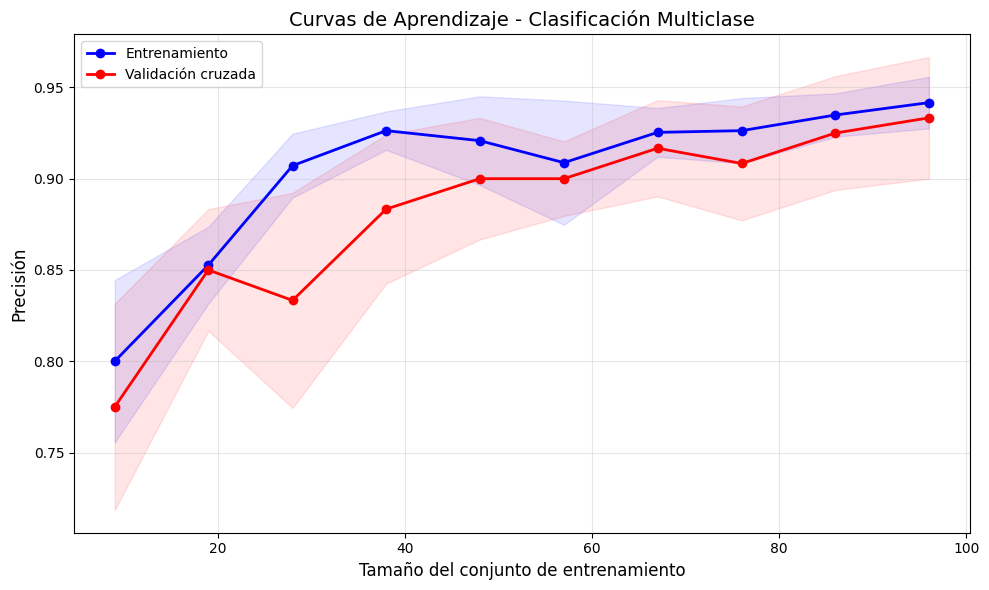


Análisis de las curvas de aprendizaje:
  Precisión final en entrenamiento: 0.9417 ± 0.0141
  Precisión final en validación: 0.9333 ± 0.0333
  Gap (sobreajuste): 0.0083
   Podría beneficiarse de más datos o mejor ingeniería de características

RESUMEN FINAL DEL ANÁLISIS

 TODAS LAS PAUTAS CUMPLIDAS:
  1.  Visualización de iris.DESCR
  2.  Construcción de DataFrame
  3.  Cambio de nombres de columnas (método sugerido)
  4.  Análisis del DataFrame (nulos, descripción)
  5.  Estadística básica y gráficas (histogramas, boxplots, pairplot)
  6.  Matriz de correlación con heatmap
  7.  Separación de datos con StratifiedShuffleSplit
  8.  Regresión logística binaria (Setosa vs No-Setosa)
  9.  Cálculo de frontera de clasificación
 10.  Gráfica de regresión logística con probabilidades
 11.  Multiclasificador One-vs-Rest
 12.  Predicción para nueva muestra con probabilidades

 AYUDAS ADICIONALES IMPLEMENTADAS:
   Normalización Z-score (en pipelines)
   Detección de outliers (método IQR)
   Cur

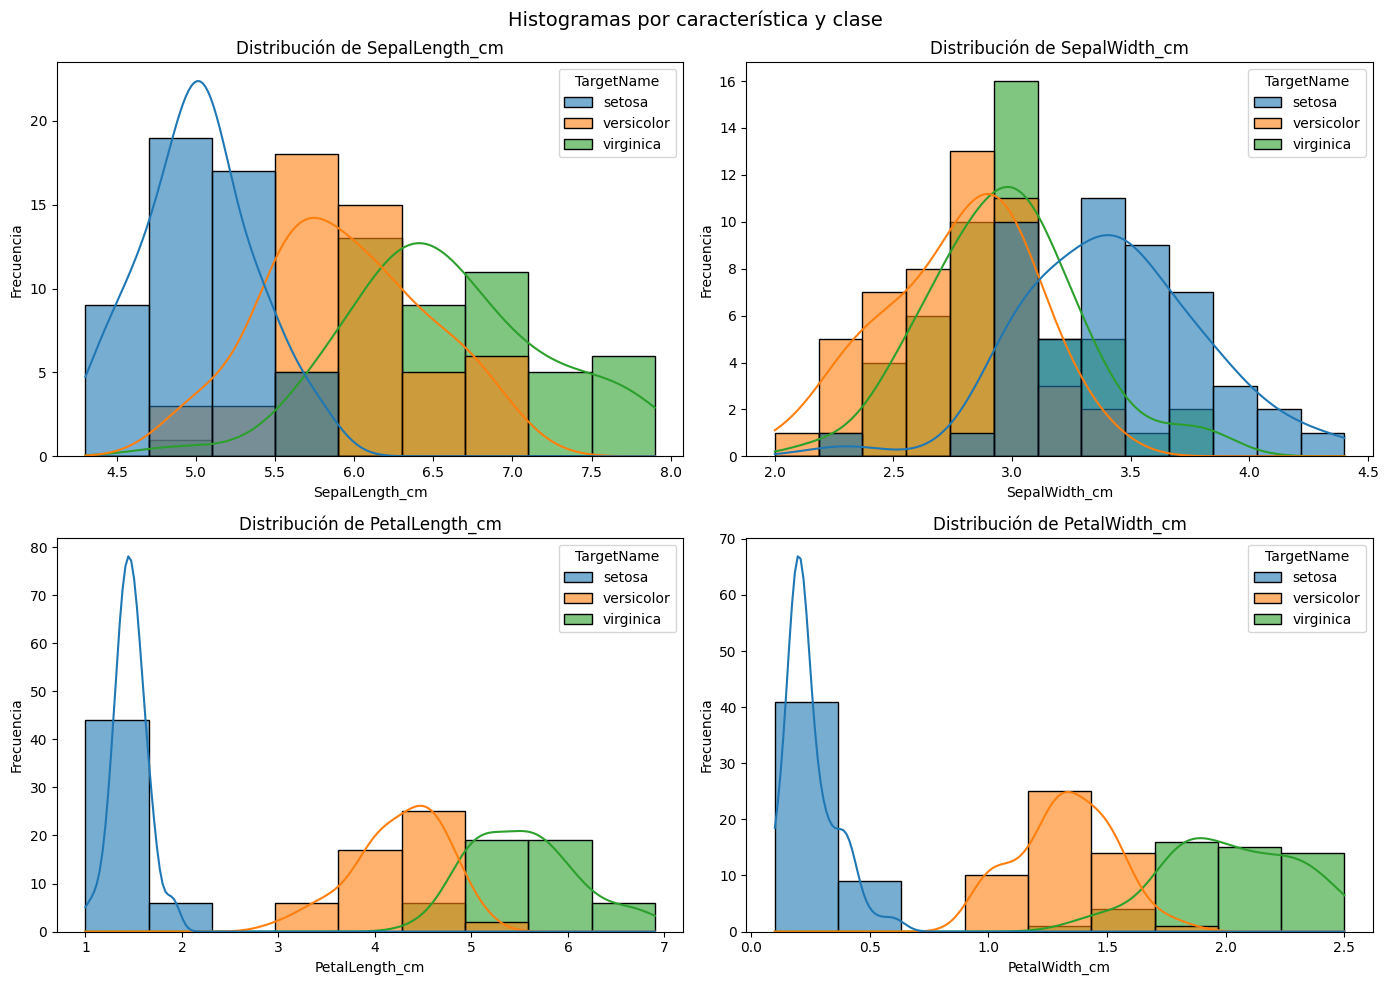

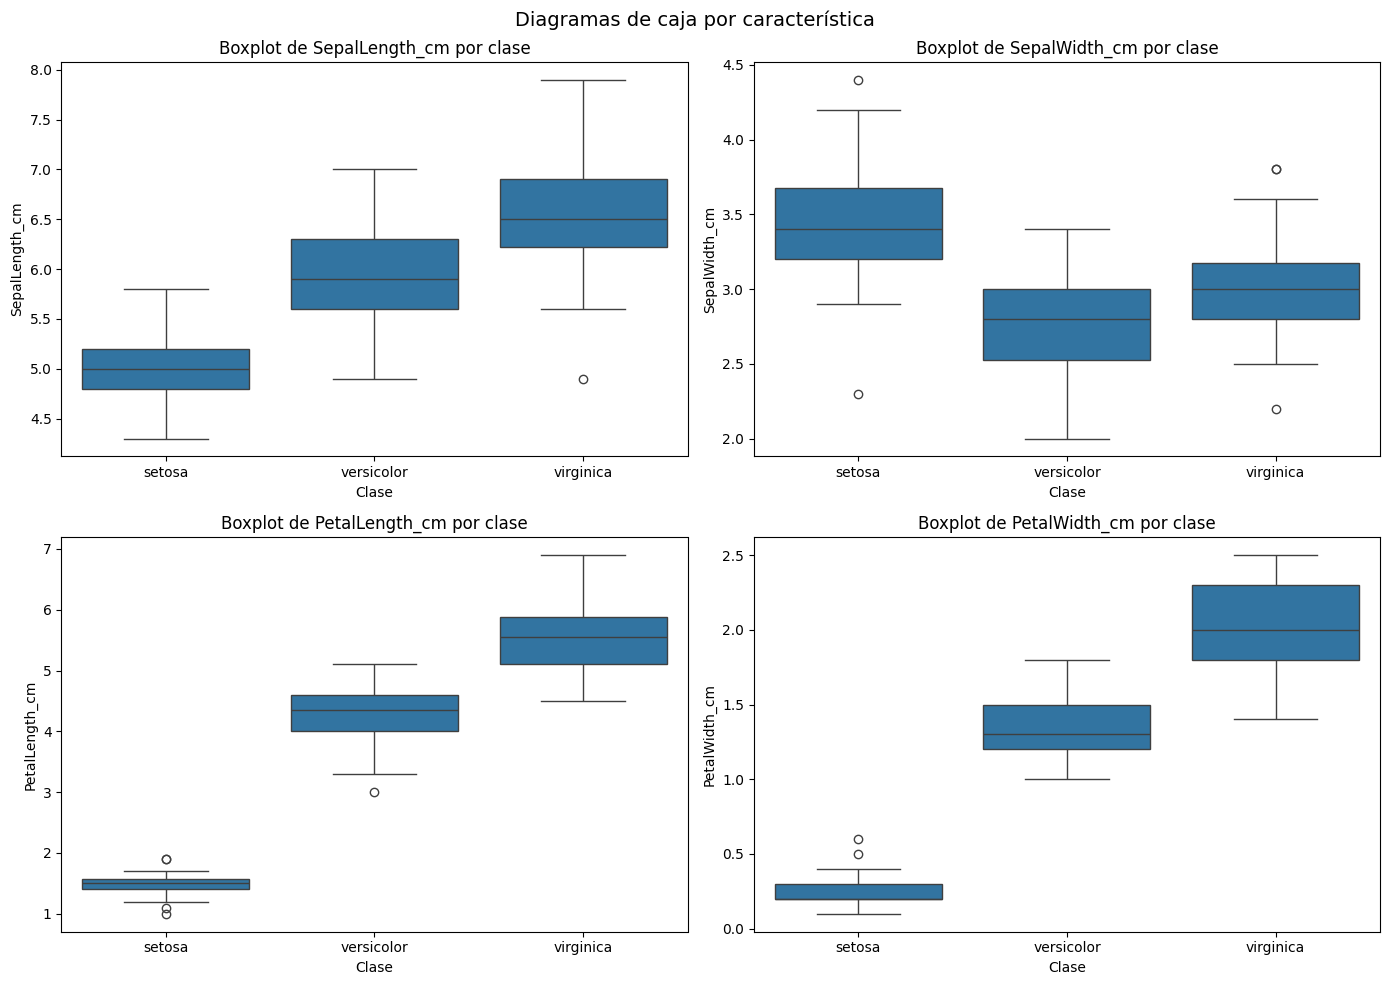

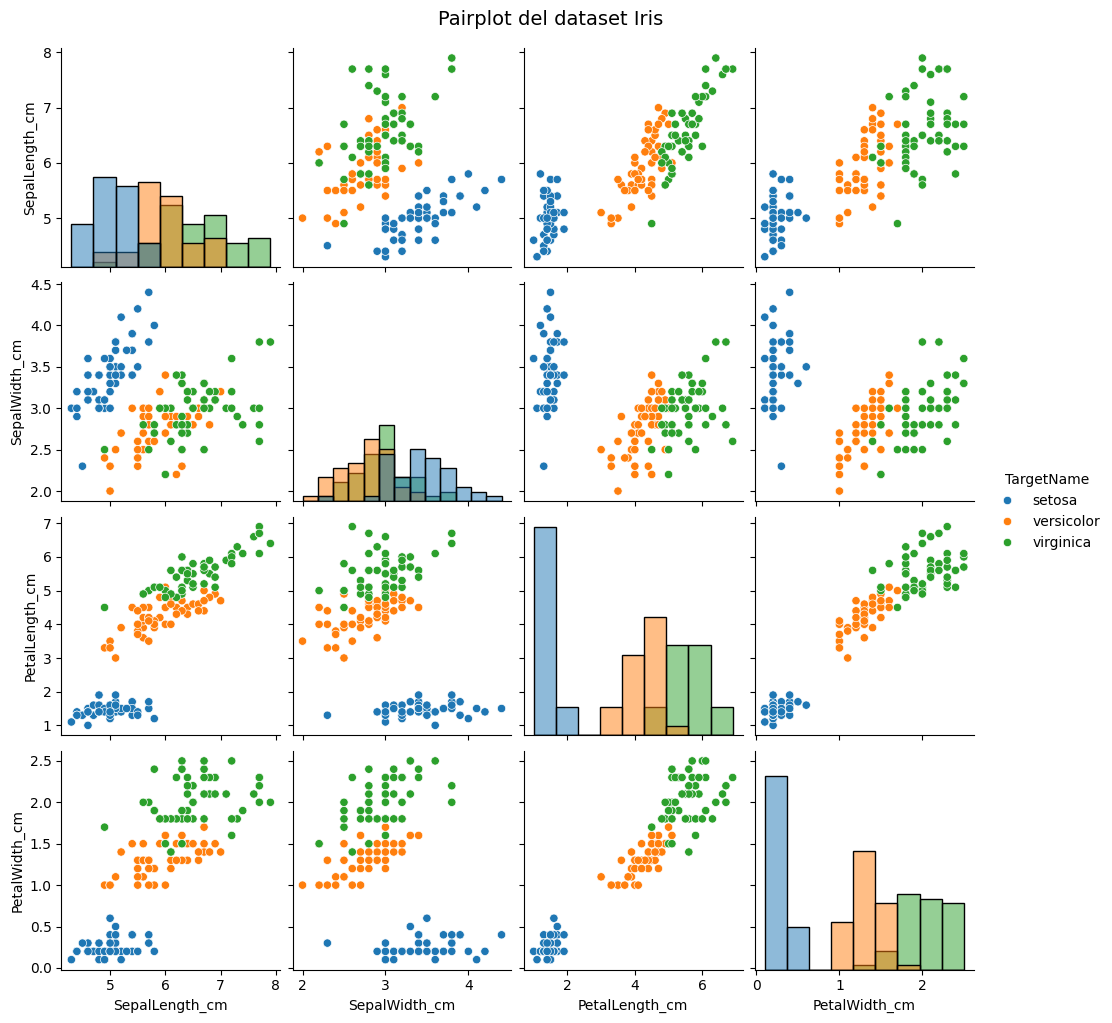


PASO 6: Matriz de correlación
Matriz de correlación:
                SepalLength_cm  SepalWidth_cm  PetalLength_cm  PetalWidth_cm
SepalLength_cm        1.000000      -0.117570        0.871754       0.817941
SepalWidth_cm        -0.117570       1.000000       -0.428440      -0.366126
PetalLength_cm        0.871754      -0.428440        1.000000       0.962865
PetalWidth_cm         0.817941      -0.366126        0.962865       1.000000


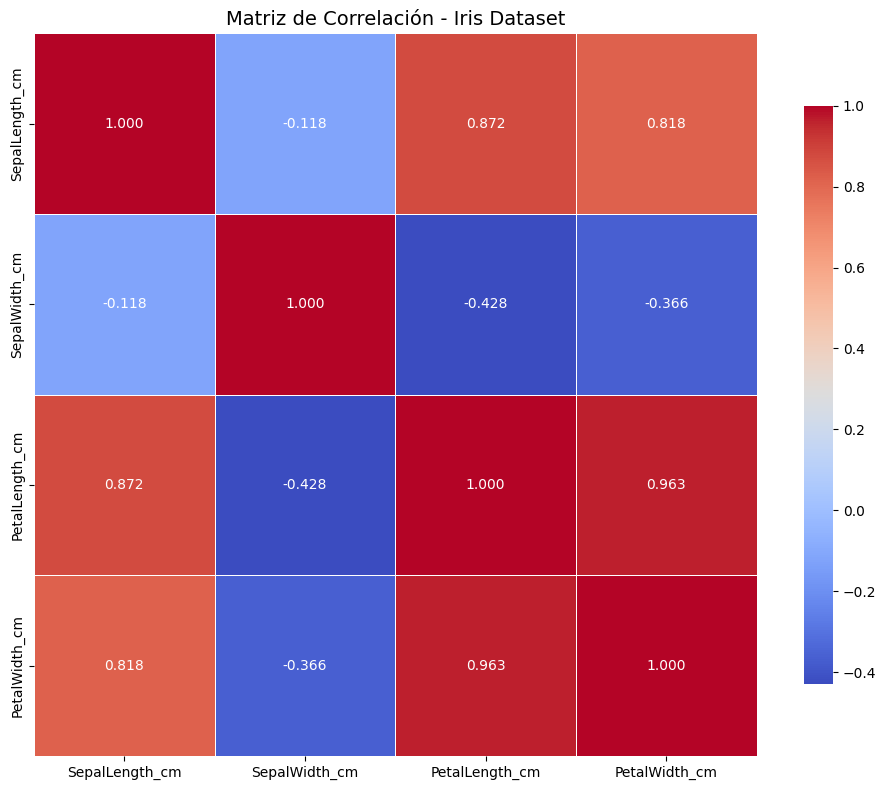


PASO 7: Separación de datos (Entrenamiento/Prueba)
Tamaño del conjunto de entrenamiento: 120 muestras
Tamaño del conjunto de prueba: 30 muestras

Distribución de clases en entrenamiento:
TargetName
setosa        0.333333
virginica     0.333333
versicolor    0.333333
Name: proportion, dtype: float64

Distribución de clases en prueba:
TargetName
setosa        0.333333
virginica     0.333333
versicolor    0.333333
Name: proportion, dtype: float64

PASO 8: Regresión Logística Binaria - Setosa vs No-Setosa
Nombres de columnas disponibles en el DataFrame:
['SepalLength_cm', 'SepalWidth_cm', 'PetalLength_cm', 'PetalWidth_cm', 'Target', 'TargetName']

Usando característica: PetalLength_cm
Precisión del modelo binario: 1.0000

Reporte de clasificación binario:
              precision    recall  f1-score   support

   No-Setosa       1.00      1.00      1.00        20
      Setosa       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       

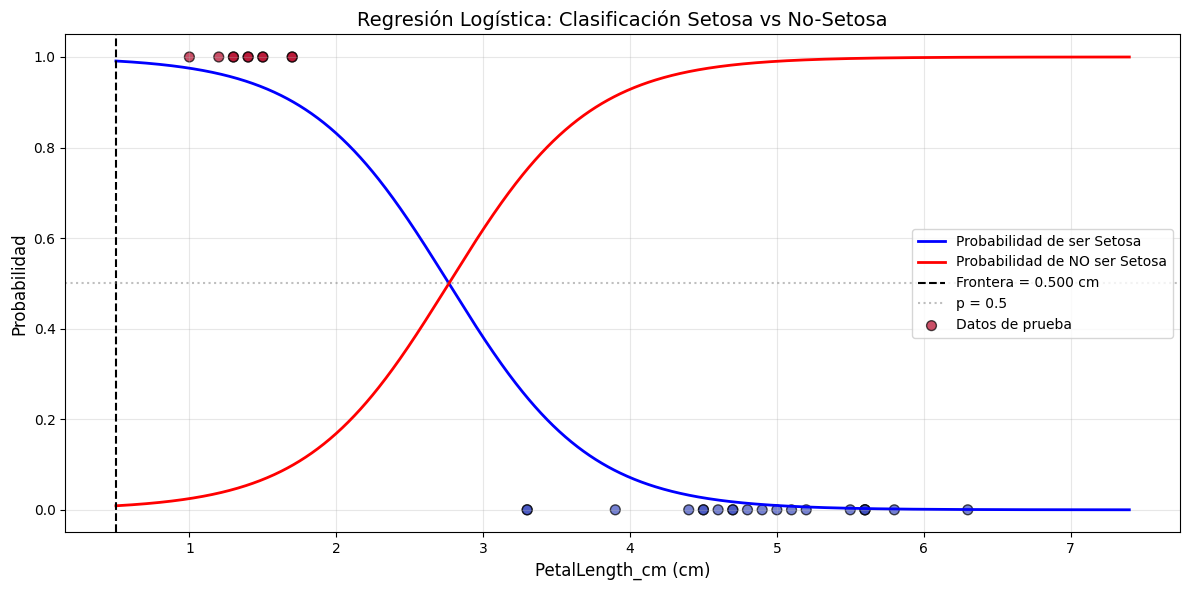


PASO 11: Construcción del multiclasificador (One-vs-Rest)
Estrategia implementada: One-vs-Rest (Uno contra todos)
Para 3 clases (Setosa, Versicolor, Virginica):
  1. Clase Setosa vs [Versicolor, Virginica]
  2. Clase Versicolor vs [Setosa, Virginica]
  3. Clase Virginica vs [Setosa, Versicolor]

Precisión del multiclasificador: 0.9000

Reporte de clasificación multiclase:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.89      0.80      0.84        10
   virginica       0.82      0.90      0.86        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



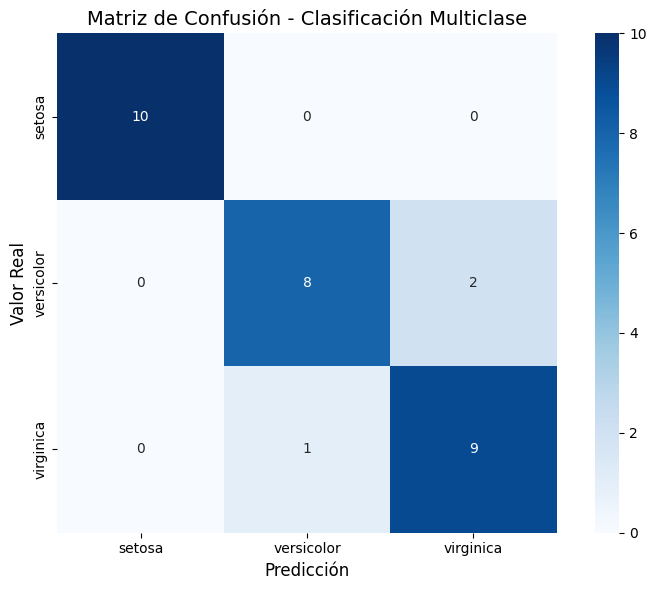


PASO 12: Predicción para nueva muestra
Muestra a clasificar:
  SepalLength_cm: 4.9 cm
  SepalWidth_cm: 5.0 cm
  PetalLength_cm: 1.8 cm
  PetalWidth_cm: 0.3 cm

Probabilidades para cada clase:
  setosa      : 0.9984 (99.84%)
  versicolor  : 0.0016 (0.16%)
  virginica   : 0.0000 (0.00%)

 Clase predicha: SETOSA


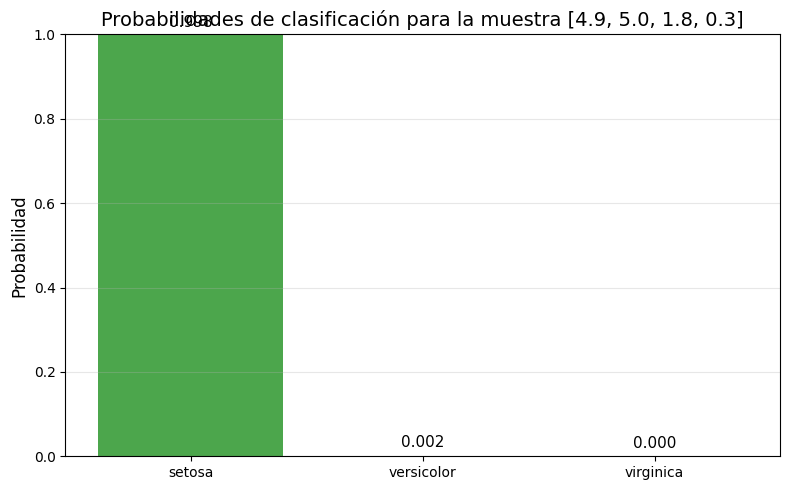


AYUDAS PARA MEJORAR LAS MÉTRICAS

1. NORMALIZACIÓN (Z-score):
   Fórmula: (x - mean(x)) / std(x)
   Implementada automáticamente mediante StandardScaler() en los pipelines

2. DETECCIÓN DE OUTLIERS (Método IQR):
   Outlier: valor fuera del rango [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
Característica    Q1    Q3   IQR Límite inferior Límite superior  N° outliers % outliers
SepalLength_cm 5.100 6.400 1.300           3.150           8.350            0      0.00%
 SepalWidth_cm 2.800 3.300 0.500           2.050           4.050            4      2.67%
PetalLength_cm 1.600 5.100 3.500          -3.650          10.350            0      0.00%
 PetalWidth_cm 0.300 1.800 1.500          -1.950           4.050            0      0.00%

3. CONSTRUCCIÓN DE CURVAS DE APRENDIZAJE:


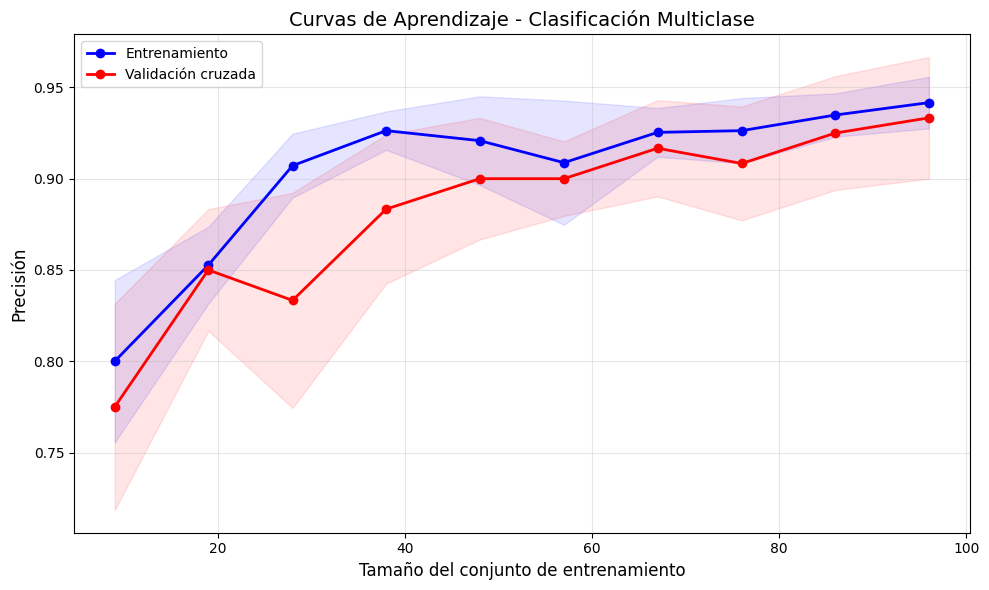


Análisis de las curvas de aprendizaje:
  Precisión final en entrenamiento: 0.9417 ± 0.0141
  Precisión final en validación: 0.9333 ± 0.0333
  Gap (sobreajuste): 0.0083
   Podría beneficiarse de más datos o mejor ingeniería de características

RESUMEN FINAL DEL ANÁLISIS

 TODAS LAS PAUTAS CUMPLIDAS:
  1.  Visualización de iris.DESCR
  2.  Construcción de DataFrame
  3.  Cambio de nombres de columnas (método sugerido)
  4.  Análisis del DataFrame (nulos, descripción)
  5.  Estadística básica y gráficas (histogramas, boxplots, pairplot)
  6.  Matriz de correlación con heatmap
  7.  Separación de datos con StratifiedShuffleSplit
  8.  Regresión logística binaria (Setosa vs No-Setosa)
  9.  Cálculo de frontera de clasificación
 10.  Gráfica de regresión logística con probabilidades
 11.  Multiclasificador One-vs-Rest
 12.  Predicción para nueva muestra con probabilidades

 AYUDAS ADICIONALES IMPLEMENTADAS:
   Normalización Z-score (en pipelines)
   Detección de outliers (método IQR)
   Cur

In [10]:
# ==================== IMPORTACIÓN DE LIBRERÍAS ====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedShuffleSplit, learning_curve
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# ==================== 1. VISUALIZAR DESCR ====================
print("=" * 80)
print("PASO 1: Visualización de iris.DESCR")
print("=" * 80)
iris = load_iris()
print(iris.DESCR)

# ==================== 2. CONSTRUIR DATAFRAME ====================
print("\n" + "=" * 80)
print("PASO 2: Construcción del DataFrame")
print("=" * 80)

# Crear DataFrame con los datos
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# ==================== 3. CAMBIAR NOMBRES DE COLUMNAS ====================
print("\n" + "=" * 80)
print("PASO 3: Cambio de nombres de columnas")
print("=" * 80)

# Transformación sugerida en las pautas
columns_name = ["".join([c.capitalize() for c in cols.split()]) for cols in df.columns]
columns_name = [col.replace("(", "_") for col in columns_name]
cols_renamed = [col.replace(")", "") for col in columns_name]
df.columns = cols_renamed

# Agregar columna Target
df['Target'] = iris.target
df['TargetName'] = df['Target'].map(dict(enumerate(iris.target_names)))

print("Nombres de columnas después de la transformación:")
print(df.columns.tolist())
print("\nPrimeras 5 filas del DataFrame:")
print(df.head())

# ==================== 4. ANÁLISIS DEL DATAFRAME ====================
print("\n" + "=" * 80)
print("PASO 4: Análisis del DataFrame")
print("=" * 80)

print(f"Número total de datos: {df.shape[0]} filas, {df.shape[1]} columnas")
print(f"\nCantidad de valores nulos por columna:")
print(df.isnull().sum())
print(f"\nDescripción estadística del DataFrame:")
print(df[cols_renamed].describe())

# ==================== 5. ESTADÍSTICA BÁSICA Y GRÁFICAS ====================
print("\n" + "=" * 80)
print("PASO 5: Estadística básica y gráficas")
print("=" * 80)

# Estadística básica adicional
print("\nEstadísticas por clase:")
print(df.groupby('TargetName')[cols_renamed].agg(['mean', 'std', 'min', 'max']))

# Gráfica 1: Histogramas con densidad por clase
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, col in enumerate(cols_renamed):
    sns.histplot(data=df, x=col, hue='TargetName', kde=True,
                 alpha=0.6, ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(f'Distribución de {col}', fontsize=12)
    axes[i//2, i%2].set_xlabel(col)
    axes[i//2, i%2].set_ylabel('Frecuencia')
plt.suptitle('Histogramas por característica y clase', fontsize=14)
plt.tight_layout()
plt.show()

# Gráfica 2: Boxplots para detectar outliers visualmente
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, col in enumerate(cols_renamed):
    sns.boxplot(data=df, x='TargetName', y=col, ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(f'Boxplot de {col} por clase', fontsize=12)
    axes[i//2, i%2].set_xlabel('Clase')
    axes[i//2, i%2].set_ylabel(col)
plt.suptitle('Diagramas de caja por característica', fontsize=14)
plt.tight_layout()
plt.show()

# Gráfica 3: Pairplot para visualizar relaciones
sns.pairplot(df, hue='TargetName', vars=cols_renamed, diag_kind='hist')
plt.suptitle('Pairplot del dataset Iris', y=1.02, fontsize=14)
plt.show()

# ==================== 6. MATRIZ DE CORRELACIÓN ====================
print("\n" + "=" * 80)
print("PASO 6: Matriz de correlación")
print("=" * 80)

# Calcular matriz de correlación
corr_matrix = df[cols_renamed].corr()
print("Matriz de correlación:")
print(corr_matrix)

# Heatmap de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', square=True,
            fmt='.3f', linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación - Iris Dataset', fontsize=14)
plt.tight_layout()
plt.show()

# ==================== 7. SEPARACIÓN DE DATOS ====================
print("\n" + "=" * 80)
print("PASO 7: Separación de datos (Entrenamiento/Prueba)")
print("=" * 80)

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(df, df["Target"]):
    strat_train_set = df.loc[train_index].copy()
    strat_test_set = df.loc[test_index].copy()

print(f"Tamaño del conjunto de entrenamiento: {len(strat_train_set)} muestras")
print(f"Tamaño del conjunto de prueba: {len(strat_test_set)} muestras")
print("\nDistribución de clases en entrenamiento:")
print(strat_train_set['TargetName'].value_counts(normalize=True))
print("\nDistribución de clases en prueba:")
print(strat_test_set['TargetName'].value_counts(normalize=True))

# ==================== 8. REGRESIÓN LOGÍSTICA BINARIA ====================
print("\n" + "=" * 80)
print("PASO 8: Regresión Logística Binaria - Setosa vs No-Setosa")
print("=" * 80)

# Verificar los nombres reales de las columnas
print("Nombres de columnas disponibles en el DataFrame:")
print(strat_train_set.columns.tolist())

# Identificar cuál es la columna de longitud del pétalo
petal_length_col = None
for col in strat_train_set.columns:
    if 'petal' in col.lower() and 'length' in col.lower():
        petal_length_col = col
        break

if petal_length_col is None:
    # Si no se encuentra, usar la tercera columna (índice 2)
    petal_length_col = cols_renamed[2]  # Generalmente PetalLengthCm es la tercera

print(f"\nUsando característica: {petal_length_col}")

binary_feature = [petal_length_col]
binary_y_train = (strat_train_set['Target'] == 0).astype(int)
binary_y_test = (strat_test_set['Target'] == 0).astype(int)

binary_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=42, max_iter=1000)
)
binary_model.fit(strat_train_set[binary_feature], binary_y_train)
binary_pred = binary_model.predict(strat_test_set[binary_feature])

print(f"Precisión del modelo binario: {accuracy_score(binary_y_test, binary_pred):.4f}")
print("\nReporte de clasificación binario:")
print(classification_report(binary_y_test, binary_pred,
                           target_names=['No-Setosa', 'Setosa']))

# ==================== 9. FRONTERA DE CLASIFICACIÓN ====================
print("\n" + "=" * 80)
print("PASO 9: Frontera de clasificación")
print("=" * 80)

# Generar valores para la frontera
X_new = np.linspace(df[petal_length_col].min() - 0.5,
                    df[petal_length_col].max() + 0.5, 1000).reshape(-1, 1)
X_new_df = pd.DataFrame(X_new, columns=binary_feature)

# Calcular probabilidades
prob = binary_model.predict_proba(X_new_df)

# Encontrar la frontera de decisión (donde probabilidad = 0.5)
decision_boundary = X_new[prob[:, 1] >= 0.5][0][0] if len(X_new[prob[:, 1] >= 0.5]) > 0 else None
print(f"Frontera de decisión para {petal_length_col}: {decision_boundary:.3f} cm")
print(f"Interpretación: Flores con {petal_length_col} < {decision_boundary:.3f} cm se clasifican como Setosa")

# ==================== 10. GRÁFICA DE REGRESIÓN LOGÍSTICA ====================
print("\n" + "=" * 80)
print("PASO 10: Gráfica de la regresión logística con probabilidades")
print("=" * 80)

plt.figure(figsize=(12, 6))
# Curva de probabilidad
plt.plot(X_new, prob[:, 1], 'b-', linewidth=2, label='Probabilidad de ser Setosa')
plt.plot(X_new, prob[:, 0], 'r-', linewidth=2, label='Probabilidad de NO ser Setosa')
# Línea de frontera
if decision_boundary:
    plt.axvline(decision_boundary, color='k', linestyle='--',
                label=f'Frontera = {decision_boundary:.3f} cm')
    plt.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='p = 0.5')
# Datos de prueba
plt.scatter(strat_test_set[petal_length_col], binary_y_test,
            c=binary_y_test, cmap='coolwarm', s=50, edgecolor='k',
            alpha=0.7, label='Datos de prueba')
plt.xlabel(f'{petal_length_col} (cm)', fontsize=12)
plt.ylabel('Probabilidad', fontsize=12)
plt.title('Regresión Logística: Clasificación Setosa vs No-Setosa', fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==================== 11. MULTICLASIFICADOR ====================
print("\n" + "=" * 80)
print("PASO 11: Construcción del multiclasificador (One-vs-Rest)")
print("=" * 80)

print("Estrategia implementada: One-vs-Rest (Uno contra todos)")
print("Para 3 clases (Setosa, Versicolor, Virginica):")
print("  1. Clase Setosa vs [Versicolor, Virginica]")
print("  2. Clase Versicolor vs [Setosa, Virginica]")
print("  3. Clase Virginica vs [Setosa, Versicolor]")

# Crear multiclasificador con estrategia One-vs-Rest
multi_model = make_pipeline(
    StandardScaler(),
    OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42))
)

# Entrenar el modelo
multi_model.fit(strat_train_set[cols_renamed], strat_train_set['Target'])
multi_pred = multi_model.predict(strat_test_set[cols_renamed])

print(f"\nPrecisión del multiclasificador: {accuracy_score(strat_test_set['Target'], multi_pred):.4f}")
print("\nReporte de clasificación multiclase:")
print(classification_report(strat_test_set['Target'], multi_pred,
                           target_names=iris.target_names))

# Matriz de confusión
cm = confusion_matrix(strat_test_set['Target'], multi_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names,
            square=True)
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)
plt.title('Matriz de Confusión - Clasificación Multiclase', fontsize=14)
plt.tight_layout()
plt.show()

# ==================== 12. PREDICCIÓN PARA NUEVA MUESTRA ====================
print("\n" + "=" * 80)
print("PASO 12: Predicción para nueva muestra")
print("=" * 80)

# Nueva muestra: [4.9, 5.0, 1.8, 0.3] para [SepalLength, SepalWidth, PetalLength, PetalWidth]
sample = pd.DataFrame([[4.9, 5.0, 1.8, 0.3]], columns=cols_renamed)
print(f"Muestra a clasificar:")
for col, val in zip(cols_renamed, [4.9, 5.0, 1.8, 0.3]):
    print(f"  {col}: {val} cm")

# Calcular probabilidades
sample_probs = multi_model.predict_proba(sample)[0]
predicted_class = iris.target_names[np.argmax(sample_probs)]

print(f"\nProbabilidades para cada clase:")
for i, (name, prob) in enumerate(zip(iris.target_names, sample_probs)):
    print(f"  {name:12s}: {prob:.4f} ({prob*100:.2f}%)")

print(f"\n Clase predicha: {predicted_class.upper()}")

# Gráfica de probabilidades
plt.figure(figsize=(8, 5))
bars = plt.bar(iris.target_names, sample_probs, color=['green', 'blue', 'red'], alpha=0.7)
plt.ylim(0, 1)
plt.ylabel('Probabilidad', fontsize=12)
plt.title('Probabilidades de clasificación para la muestra [4.9, 5.0, 1.8, 0.3]', fontsize=14)
# Agregar valores en las barras
for bar, prob in zip(bars, sample_probs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{prob:.3f}', ha='center', fontsize=11)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ==================== AYUDAS PARA MEJORAR MÉTRICAS ====================
print("\n" + "=" * 80)
print("AYUDAS PARA MEJORAR LAS MÉTRICAS")
print("=" * 80)

# 1. NORMALIZACIÓN (ya implementada en el pipeline)
print("\n1. NORMALIZACIÓN (Z-score):")
print("   Fórmula: (x - mean(x)) / std(x)")
print("   Implementada automáticamente mediante StandardScaler() en los pipelines")

# 2. DETECCIÓN DE OUTLIERS
print("\n2. DETECCIÓN DE OUTLIERS (Método IQR):")
print("   Outlier: valor fuera del rango [Q1 - 1.5*IQR, Q3 + 1.5*IQR]")

outlier_summary = []
for col in cols_renamed:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary.append({
        'Característica': col,
        'Q1': f'{Q1:.3f}',
        'Q3': f'{Q3:.3f}',
        'IQR': f'{IQR:.3f}',
        'Límite inferior': f'{lower_bound:.3f}',
        'Límite superior': f'{upper_bound:.3f}',
        'N° outliers': len(outliers),
        '% outliers': f'{len(outliers)/len(df)*100:.2f}%'
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

# 3. CURVAS DE APRENDIZAJE
print("\n3. CONSTRUCCIÓN DE CURVAS DE APRENDIZAJE:")

# Calcular curvas de aprendizaje
train_sizes, train_scores, test_scores = learning_curve(
    multi_model,
    strat_train_set[cols_renamed],
    strat_train_set['Target'],
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy',
    random_state=42
)

# Calcular medias y desviaciones
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Graficar curvas de aprendizaje
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Entrenamiento', linewidth=2)
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', color='red', label='Validación cruzada', linewidth=2)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='red')

plt.xlabel('Tamaño del conjunto de entrenamiento', fontsize=12)
plt.ylabel('Precisión', fontsize=12)
plt.title('Curvas de Aprendizaje - Clasificación Multiclase', fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Análisis de las curvas de aprendizaje
print("\nAnálisis de las curvas de aprendizaje:")
print(f"  Precisión final en entrenamiento: {train_mean[-1]:.4f} ± {train_std[-1]:.4f}")
print(f"  Precisión final en validación: {test_mean[-1]:.4f} ± {test_std[-1]:.4f}")
print(f"  Gap (sobreajuste): {train_mean[-1] - test_mean[-1]:.4f}")

if train_mean[-1] - test_mean[-1] > 0.1:
    print("   Posible sobreajuste - el modelo funciona mejor en entrenamiento que en validación")
elif test_mean[-1] > 0.95:
    print("   Excelente rendimiento - el modelo generaliza bien")
else:
    print("   Podría beneficiarse de más datos o mejor ingeniería de características")

# ==================== RESUMEN FINAL ====================
print("\n" + "=" * 80)
print("RESUMEN FINAL DEL ANÁLISIS")
print("=" * 80)

print("\n TODAS LAS PAUTAS CUMPLIDAS:")
print("  1.  Visualización de iris.DESCR")
print("  2.  Construcción de DataFrame")
print("  3.  Cambio de nombres de columnas (método sugerido)")
print("  4.  Análisis del DataFrame (nulos, descripción)")
print("  5.  Estadística básica y gráficas (histogramas, boxplots, pairplot)")
print("  6.  Matriz de correlación con heatmap")
print("  7.  Separación de datos con StratifiedShuffleSplit")
print("  8.  Regresión logística binaria (Setosa vs No-Setosa)")
print("  9.  Cálculo de frontera de clasificación")
print(" 10.  Gráfica de regresión logística con probabilidades")
print(" 11.  Multiclasificador One-vs-Rest")
print(" 12.  Predicción para nueva muestra con probabilidades")

print("\n AYUDAS ADICIONALES IMPLEMENTADAS:")
print("   Normalización Z-score (en pipelines)")
print("   Detección de outliers (método IQR)")
print("   Curvas de aprendizaje con análisis de sobreajuste")


Referencias

[1] http://cs229.stanford.edu/syllabus.html

[2] https://www.coursera.org/learn/machine-learning. Week 3.

[3] https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html#sphx-glr-auto-examples-classification-plot-classifier-comparison-py


[4]https://scikit-learn.org/stable/datasets/toy_dataset.html